# Практика: DBSCAN — плотностная кластеризация

## Что вы сделаете
В этом ноутбуке вы:

1. исследуете нелинейные 2D-датасеты и убедитесь в ограничениях K-Means;
2. построите **k-distance plot** и выберете оптимальный параметр `eps`;
3. применените **DBSCAN** и проанализируете результаты;
4. сравните DBSCAN с K-Means на нелинейных данных;
5. исследуете влияние гиперпараметров `eps` и `min_samples`;
6. применените DBSCAN к реальному датасету **Wine** и проанализируете шумовые точки;
7. сравните силуэт DBSCAN и K-Means, сделаете выводы.

## Важно
- Заполняйте все ячейки с пометкой `# YOUR CODE HERE`.
- Не удаляйте проверки: они подскажут, правильно ли вы идёте.
- Вопросы для размышления помогут вам глубже понять алгоритм.

## Датасеты
- **`make_moons`** и **`make_circles`** из `sklearn.datasets`: 2D-данные с нелинейными кластерами.
- **Wine** (`load_wine`): реальный многомерный датасет (13 признаков, 3 класса).

## Что сдавать
1. Заполненный ноутбук со всеми графиками.
2. Краткие выводы в конце каждого раздела.
3. Итоговый вывод: когда DBSCAN лучше K-Means и когда нет.

## Краткая теория

### Типы точек в DBSCAN

DBSCAN задаётся двумя параметрами: радиусом окрестности `eps` (ε) и минимальным числом точек `min_samples`.

- **Корневая точка** (core): в её ε-окрестности ≥ `min_samples` точек.
- **Граничная точка** (border): в её ε-окрестности < `min_samples`, но она достижима из корневой.
- **Шумовая точка** (noise): не является ни корневой, ни граничной → метка **-1**.

### Как работает алгоритм

1. Для каждой непосещённой точки найти её ε-окрестность.
2. Если точек ≥ `min_samples` — начать новый кластер.
3. Рекурсивно расширить кластер через цепочки плотно достижимых точек.
4. Оставшиеся точки → шум (метка -1).

### Как выбрать eps: k-distance plot

Для каждой точки вычисляют расстояние до её k-го ближайшего соседа (k = `min_samples`). Отсортированный по убыванию график этих расстояний называется **k-distance plot**. Резкий перегиб («локоть») указывает на оптимальное значение `eps`.

---
## Шаг 1. Импорты и настройки

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_moons, make_circles, load_wine
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Импорты выполнены успешно!")

Импорты выполнены успешно!


---
## Шаг 2. Исследование нелинейных датасетов

Сгенерируем два датасета, с которыми K-Means заведомо не справится.

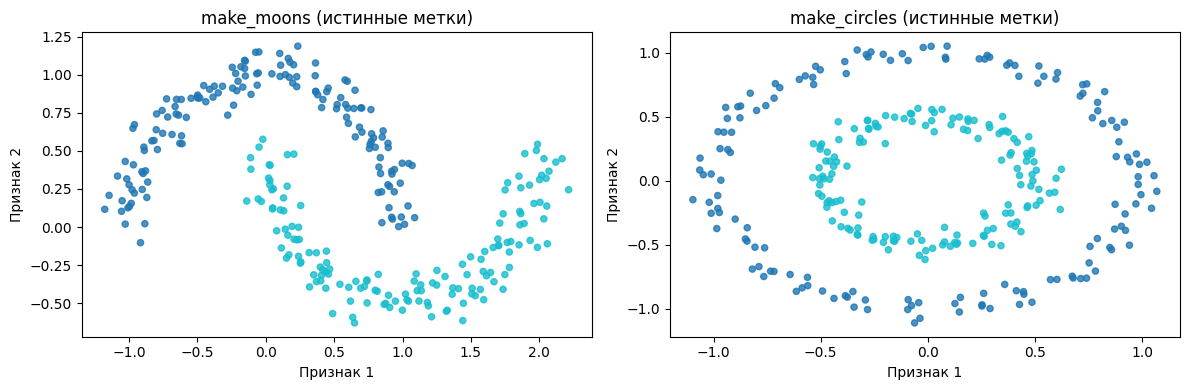

In [74]:
# Генерация датасетов
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=RANDOM_STATE)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05,
                                     factor=0.5, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=y_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("make_moons (истинные метки)")
axes[0].set_xlabel("Признак 1")
axes[0].set_ylabel("Признак 2")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=y_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("make_circles (истинные метки)")
axes[1].set_xlabel("Признак 1")
axes[1].set_ylabel("Признак 2")

plt.tight_layout()
plt.show()

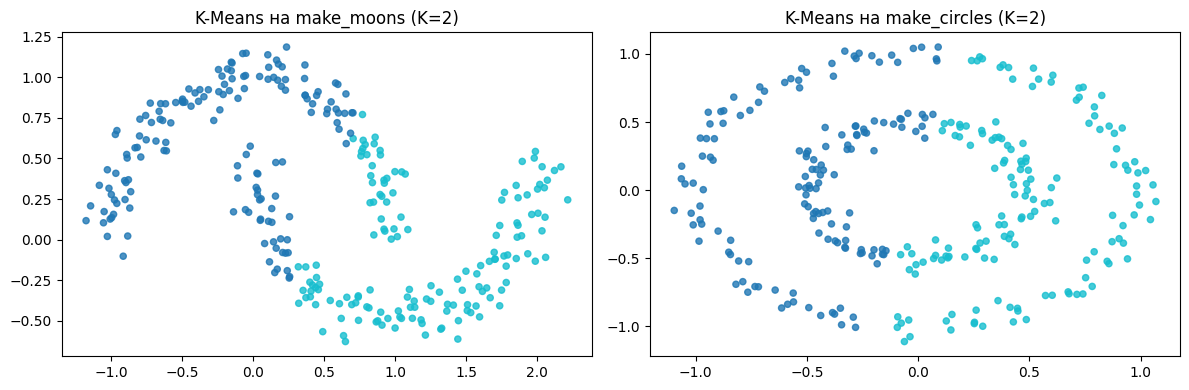

In [75]:
# Применим K-Means к этим датасетам
# YOUR CODE HERE
# 1. Создайте KMeans с n_clusters=2, random_state=RANDOM_STATE
# 2. Обучите на X_moons и X_circles
# 3. Получите метки кластеров

kmeans_moons = KMeans(n_clusters=2, random_state=RANDOM_STATE)
labels_km_moons = kmeans_moons.fit_predict(X_moons)
kmeans_circles = KMeans(n_clusters=2, random_state=RANDOM_STATE)
labels_km_circles = kmeans_circles.fit_predict(X_circles)

# Визуализация результатов K-Means
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=labels_km_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("K-Means на make_moons (K=2)")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=labels_km_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("K-Means на make_circles (K=2)")

plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** Почему K-Means не может правильно разделить «луны» и «кольца»? Связано ли это с формой функционала ошибки?

K-means выбирает центроиды, которые могут оказаться вне самих фигур. Поскольку такие формы являются вогнутыми или тороидальными/кольцеобразными, среднее геометрическое точек  часто попадает в пустое пространство за пределами самой фигуры (или вообще в другой кластер).

K-means оценивает только евклидово расстояние. Ближайшая по прямой линии точка не обязательно принадлежит к тому же кластеру, так как обычное евклидово расстояние не учитывает непрерывность, форму и топологию данных.

---
## Шаг 3. k-Distance Plot и выбор eps

Построим k-distance plot для датасета `make_moons`. Используем k = 5 (= `min_samples`).

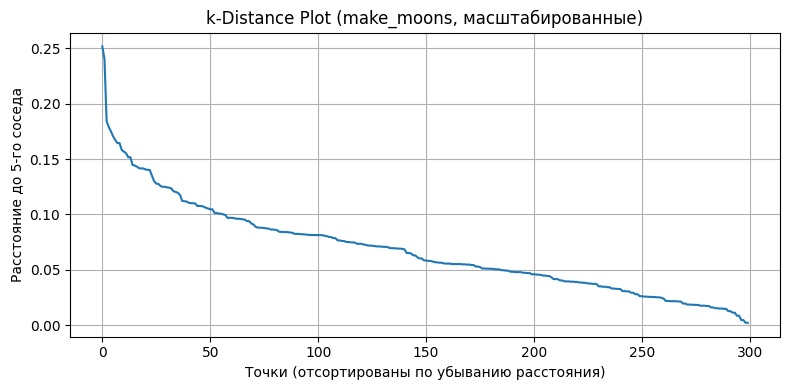

Найдите 'локоть' на графике и запишите подходящее значение eps:


In [76]:
# Масштабируем данные
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

k = 5

# YOUR CODE HERE
# 1. Создайте NearestNeighbors(n_neighbors=k) и обучите на X_moons_scaled
# 2. Вызовите .kneighbors() для получения матрицы расстояний
# 3. Возьмите расстояние до k-го соседа (последний столбец distances)
# 4. Отсортируйте по убыванию

k_distances_moons = NearestNeighbors(n_neighbors=k).fit(X_moons_scaled).kneighbors(X_moons_scaled)[0][:, 1]
k_distances_moons = np.sort(k_distances_moons)[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_distances_moons)
plt.xlabel("Точки (отсортированы по убыванию расстояния)")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.title("k-Distance Plot (make_moons, масштабированные)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Найдите 'локоть' на графике и запишите подходящее значение eps:")

**❓ Вопрос для размышления:** Где находится «локоть»? Как он указывает на границу между точками кластеров и шумом?


Локоть находится примерно на K-distance = 0.11. Локоть указывает как раз на разделение шума и кластеров. справа от локтя у точек расстояние до 5-ого соседа меньше, чем у тех, что слева от локтя. это логично, тк шумные точки лежат далеко от других, а кластерные - все рядом.

---
## Шаг 4. DBSCAN на нелинейных датасетах

Применим DBSCAN к `make_moons` и `make_circles`. Обратите внимание на масштабирование.

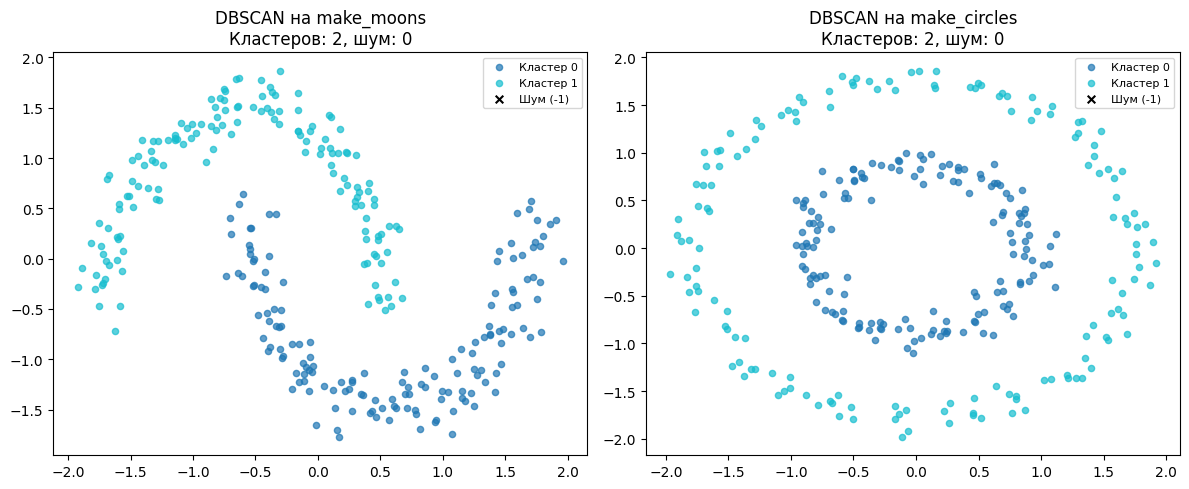

In [77]:
# Масштабируем make_circles
scaler_circles = StandardScaler()
X_circles_scaled = scaler_circles.fit_transform(X_circles)

# YOUR CODE HERE
# 1. Создайте DBSCAN с подобранным eps (из k-distance plot) и min_samples=5
# 2. Примените fit_predict к X_moons_scaled и X_circles_scaled
# 3. Подберите параметры так, чтобы алгоритм нашёл 2 кластера

db_moons = DBSCAN(eps=0.3, min_samples=5)       # eps=0.3 я использовал, потому что при 0.11 из задания с K-distance plot получилось слишком много кластеров и шумов
labels_db_moons = db_moons.fit_predict(X_moons_scaled)

db_circles = DBSCAN(eps=0.35, min_samples=5)
labels_db_circles = db_circles.fit_predict(X_circles_scaled)

# Вспомогательная функция для визуализации
def plot_dbscan_results(X, labels, title, ax):
    """Визуализирует результаты DBSCAN.
    Корневые точки — крупные, граничные — обычные, шум — крестики."""
    noise_mask = labels == -1
    colors = cm.tab10(np.linspace(0, 1, max(labels)+1)) if max(labels) >= 0 else []
    
    for i in range(max(labels)+1):
        mask = labels == i
        ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7,
                   color=colors[i], label=f'Кластер {i}')
    
    ax.scatter(X[noise_mask, 0], X[noise_mask, 1],
               s=30, c='black', marker='x', label='Шум (-1)')
    
    n_cl = max(labels) + 1 if max(labels) >= 0 else 0
    n_noise = noise_mask.sum()
    ax.set_title(f"{title}\nКластеров: {n_cl}, шум: {n_noise}")
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_dbscan_results(X_moons_scaled, labels_db_moons, "DBSCAN на make_moons", axes[0])
plot_dbscan_results(X_circles_scaled, labels_db_circles, "DBSCAN на make_circles", axes[1])
plt.tight_layout()
plt.show()

---
## Шаг 5. Сравнение DBSCAN и K-Means на нелинейных данных

In [78]:
# Сравнение силуэта DBSCAN vs K-Means для make_moons

# YOUR CODE HERE
# 1. Обучите KMeans(n_clusters=2) на X_moons_scaled
# 2. Вычислите silhouette_score для K-Means
# 3. Вычислите silhouette_score для DBSCAN (только для некластерных точек!)
#    Подсказка: исключите точки с labels == -1

score_kmeans = silhouette_score(X_moons_scaled, KMeans(n_clusters=2).fit_predict(X_moons_scaled))  # замените
score_dbscan = silhouette_score(X_moons_scaled[labels_db_moons != -1], labels_db_moons[labels_db_moons != -1])

print("=== Коэффициент силуэта на make_moons ===")
print(f"K-Means (K=2): {score_kmeans:.3f}" if score_kmeans is not None else "K-Means: не вычислен")
print(f"DBSCAN:        {score_dbscan:.3f}" if score_dbscan is not None else "DBSCAN: не вычислен")

=== Коэффициент силуэта на make_moons ===
K-Means (K=2): 0.494
DBSCAN:        0.380


**❓ Вопрос для размышления:** Какой алгоритм получил лучший силуэт? Соответствует ли это визуальному впечатлению? Можно ли всегда доверять силуэту как абсолютной мере качества?

K-means разрезал данные на два куска и выбил бОльшую метрику, чем DBSCAN, который разделил кластеры идеально. Это связано с тем, что они используют одинаковую Евклидову метрику для оценки расстояний. коэффициент силуэта увеличивается, если кластеры плотные и далеко от другого кластера. Силуэт не оценивает неприрывность кластеров. Вывод: НЕТ, мы не можем опираться на силуэт при вогнутых данных, тороидах и изгибах. Силуэт хорошо работает с круглыми формами. На нелинейных данных ему нельзя вслепую верить.

---
## Шаг 6. Исследование влияния гиперпараметров

Посмотрим, как меняется результат DBSCAN при разных значениях `eps` и `min_samples`.

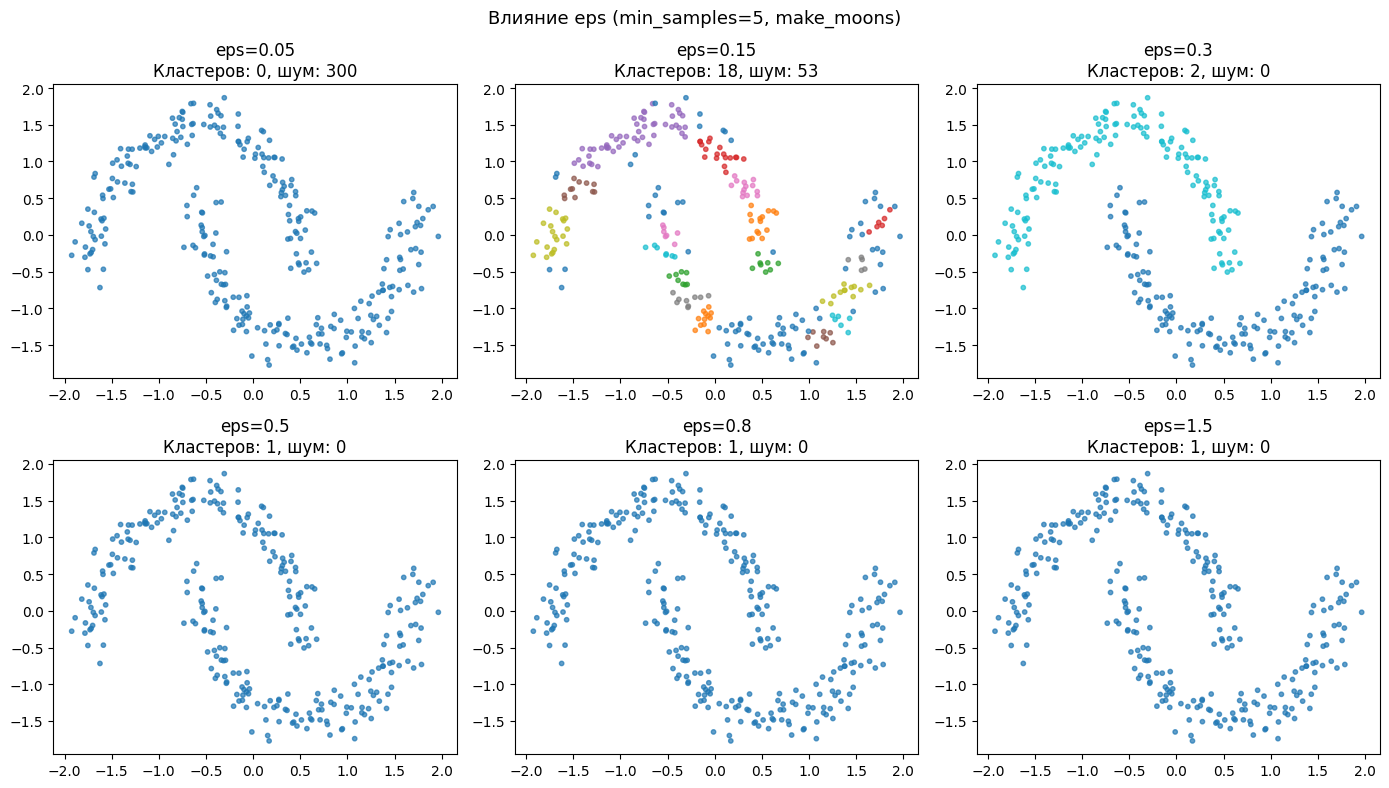

In [79]:
# Сетка eps при фиксированном min_samples=5
eps_values = [0.05, 0.15, 0.3, 0.5, 0.8, 1.5]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, eps_val in enumerate(eps_values):
    # YOUR CODE HERE
    # 1. Запустите DBSCAN(eps=eps_val, min_samples=5) на X_moons_scaled
    # 2. Получите метки
    # 3. Посчитайте число кластеров и шумовых точек
    # 4. Отобразите scatter plot с цветами по меткам
    #    Шумовые точки (label == -1) рисуйте чёрными крестиками
    labels_i = DBSCAN(eps=eps_val, min_samples=5).fit_predict(X_moons_scaled)
    
    if labels_i is not None:
        n_cl = len(set(labels_i)) - (1 if -1 in labels_i else 0)
        n_noise = (labels_i == -1).sum()
        axes[i].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1],
                        c=labels_i, cmap='tab10', s=10, alpha=0.7)
        axes[i].set_title(f"eps={eps_val}\nКластеров: {n_cl}, шум: {n_noise}")
    else:
        axes[i].set_title(f"eps={eps_val} (не вычислено)")

plt.suptitle("Влияние eps (min_samples=5, make_moons)", fontsize=13)
plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** При каком `eps` алгоритм нашёл два правильных кластера? Что происходит при слишком малом и слишком большом значении?

два правильных кластера DBSCAN нашел при eps=0.3. При увеличении eps он начинает относить точки второго кластера к первому, из-за чего мы получаем только один кластер. при низком eps из-за расстояния и плотности точек в кластере мы иногда не можем получить 5 точек, которые "дотянутся" до следующей, и кластеры выходят рваными и шумными.

---
## Шаг 7. DBSCAN на реальном датасете Wine

Теперь перейдём к реальным данным. Датасет Wine: 178 образцов вина из трёх сортов винограда, 13 химических признаков.

In [80]:
# Загрузка датасета Wine
wine = load_wine()
X_wine = wine.data
y_wine = wine.target  # истинные метки (не используем при кластеризации!)
feature_names = wine.feature_names

print(f"Форма данных: {X_wine.shape}")
print(f"Признаки: {feature_names}")
print(f"\nСтатистика признаков:")
df_wine = pd.DataFrame(X_wine, columns=feature_names)
print(df_wine.describe().round(2))

Форма данных: (178, 13)
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Статистика признаков:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00             

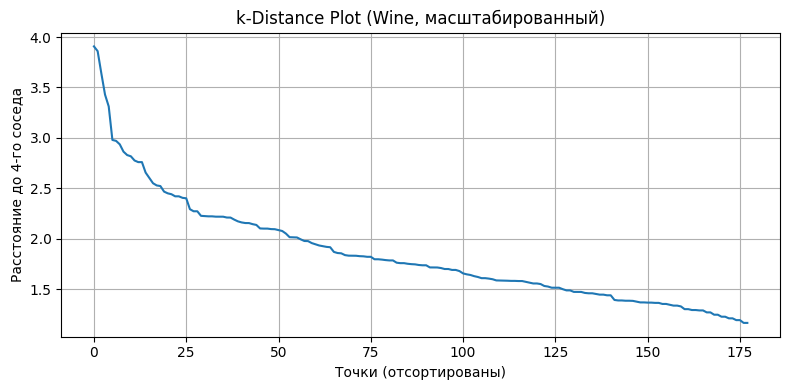

In [81]:
# YOUR CODE HERE
# 1. Масштабируйте X_wine с помощью StandardScaler
# 2. Постройте k-distance plot (k=4)
# 3. Визуально определите «локоть» и запишите подходящее eps

X_wine_scaled = StandardScaler().fit_transform(X_wine)
k_wine = 4
k_dist_wine = NearestNeighbors(n_neighbors=k_wine).fit(X_wine_scaled).kneighbors(X_wine_scaled)[0][:, 1]
k_dist_wine = np.sort(k_dist_wine)[::-1]

plt.figure(figsize=(8, 4))
if k_dist_wine is not None:
    plt.plot(k_dist_wine)
plt.xlabel("Точки (отсортированы)")
plt.ylabel(f"Расстояние до {k_wine}-го соседа")
plt.title("k-Distance Plot (Wine, масштабированный)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [86]:
# YOUR CODE HERE
# 1. Запустите DBSCAN на X_wine_scaled с выбранным eps и min_samples=4
# 2. Выведите: число кластеров, число шумовых точек, долю шума
# 3. Если кластеров > 1, вычислите силуэт (исключив шум)

eps_wine = 1.5

labels_wine = DBSCAN(eps=eps_wine, min_samples=4).fit_predict(X_wine_scaled)

print("=== Результаты DBSCAN на Wine ===")
if labels_wine is not None:
    n_clusters = len(set(labels_wine)) - (1 if -1 in labels_wine else 0)
    n_noise = (labels_wine == -1).sum()
    noise_ratio = n_noise / len(labels_wine)
    print(f"Число кластеров: {n_clusters}")
    print(f"Число шумовых точек: {n_noise}")
    print(f"Доля шума: {noise_ratio:.2%}")
    
    if n_clusters > 1:
        silhouette = silhouette_score(X_wine_scaled[labels_wine != -1], labels_wine[labels_wine != -1])
        print(f"Коэффициент силуэта (без шума): {silhouette:.3f}")

=== Результаты DBSCAN на Wine ===
Число кластеров: 2
Число шумовых точек: 169
Доля шума: 94.94%
Коэффициент силуэта (без шума): 0.407


---
## Шаг 8. Анализ шумовых точек

Шумовые точки — это объекты, которые DBSCAN не смог отнести ни к одному кластеру. В задаче кластеризации они могут нести важную информацию.

In [87]:
# YOUR CODE HERE
# 1. Выберите строки X_wine, соответствующие шумовым точкам (labels_wine == -1)
# 2. Создайте DataFrame с признаками шумовых точек
# 3. Сравните среднее значение признаков шумовых точек
#    со средним по всей выборке (df_wine.mean())
# 4. Какие признаки у шумовых точек сильно отличаются от среднего?

noise_mask_wine = X_wine[labels_wine == -1]
X_wine_noise = pd.DataFrame(noise_mask_wine, columns=feature_names)

print("=== Средние значения признаков ===")
print("Средние по всей выборке:")
print(df_wine.mean().round(2))
print("\nСредние по шумовым точкам:")
print(X_wine_noise.mean().round(2)) 

=== Средние значения признаков ===
Средние по всей выборке:
alcohol                          13.00
malic_acid                        2.34
ash                               2.37
alcalinity_of_ash                19.49
magnesium                        99.74
total_phenols                     2.30
flavanoids                        2.03
nonflavanoid_phenols              0.36
proanthocyanins                   1.59
color_intensity                   5.06
hue                               0.96
od280/od315_of_diluted_wines      2.61
proline                         746.89
dtype: float64

Средние по шумовым точкам:
alcohol                          12.96
malic_acid                        2.37
ash                               2.36
alcalinity_of_ash                19.63
magnesium                        99.04
total_phenols                     2.26
flavanoids                        1.97
nonflavanoid_phenols              0.36
proanthocyanins                   1.58
color_intensity                   5.00


**❓ Вопрос для размышления:** Чем отличаются шумовые точки от остальных? Являются ли они «плохими» данными или это реальные аномалии?

у шумных точек занижен пролин, значительно больше магния и немного меньший процент алкоголя. Это вполне реальные данные, возможно, некачественные экземпляры, или просто отклонения. Например, виноград собрали раньше или он рос в богатом минералами грунте.

---
## Шаг 9. Итоговое сравнение: DBSCAN vs K-Means на Wine

Коэффициент силуэта для K-Means: 0.560
Коэффициент силуэта для DBSCAN: 0.570


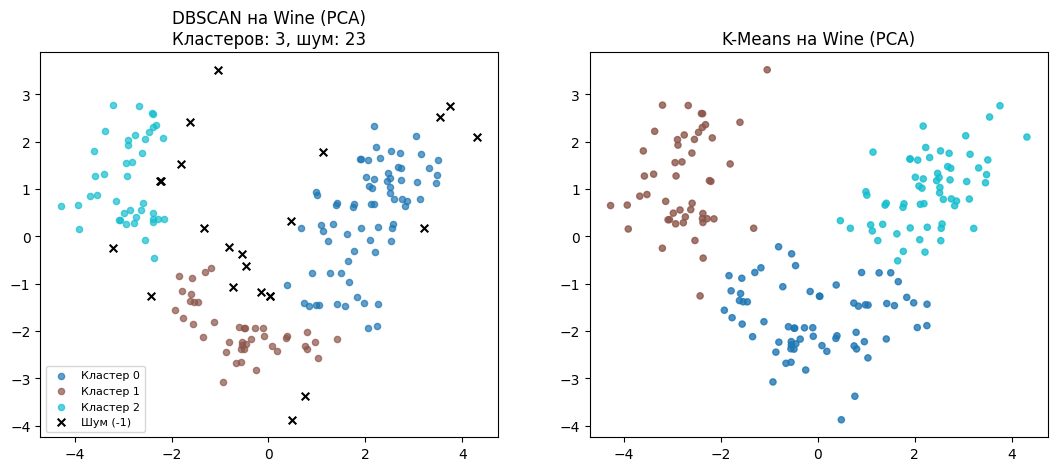

In [ ]:
# YOUR CODE HERE
# 1. Обучите KMeans с числом кластеров = числу кластеров DBSCAN
#    (или с n_clusters=3, так как истинных классов 3)
# 2. Вычислите силуэт для K-Means
# 3. Сравните силуэт DBSCAN и K-Means
# 4. Визуализируйте результаты обоих методов в 2D (первые два признака
#    после масштабирования или используйте PCA до 2 компонент)

# Подсказка для PCA:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_wine_2d = pca.fit_transform(X_wine_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# DBSCAN
dbscan_labels_2d = DBSCAN(eps=0.55, min_samples=5).fit_predict(X_wine_2d) #eps и min_samples я подобрал экспериментально, так как при 3.0-2.0 из "локтя" на k-distance plot получался один кластер.

# K-Means
kmeans_labels_2d = KMeans(n_clusters=3, random_state=RANDOM_STATE).fit_predict(X_wine_2d)

silhouette_score_kmeans = silhouette_score(X_wine_2d, kmeans_labels_2d)
silhouette_score_dbscan = silhouette_score(X_wine_2d[dbscan_labels_2d != -1], dbscan_labels_2d[dbscan_labels_2d != -1])
print(f"Коэффициент силуэта для K-Means: {silhouette_score_kmeans:.3f}")
print(f"Коэффициент силуэта для DBSCAN: {silhouette_score_dbscan:.3f}")

plot_dbscan_results(X_wine_2d, dbscan_labels_2d, "DBSCAN на Wine (PCA)", axes[0])
axes[1].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1], c=kmeans_labels_2d, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("K-Means на Wine (PCA)")
plt.show()

---
## Шаг 10. Итоговые выводы

Ответьте на следующие вопросы в ячейке ниже (текст Markdown):

**1. Когда DBSCAN выигрывает у K-Means?**

> На нелинейных данных, на вогнутых данных, ~~пончиках~~ тороидах.

**2. Когда K-Means предпочтительнее?**

> Если кластеры круглой, выпуклой формы, если визуально по графику PCA мы можем увидеть, что K-means сможет логично расположить центроиды, когда понимаем, что для DBSCAN мы не сможем подобрать рабочий eps. 

**3. Почему масштабирование обязательно для DBSCAN?**

> DBSCAN основан на том, что точки присоединяются к кластеру на основе того, есть ли в расстоянии eps min_samples точек. если данные не отмасштабированы, этот самый eps будет считаться по признакам с наибольшими значениями, а расстояния по другим признакам не будут сильно влиять на расстояние, даже если в процентах отличие между ними колоссальное.

**4. Как интерпретировать шумовые точки в датасете Wine?**

> Здесь это, вероятнее всего, не плохие данные, а реальные экземпляры, которые сделаны из вингорада, росшего в особенных условиях, или собранного раньше или позже необходимого времени. например, высокий магний в шумных точках объясняется высоким содержанием минералов в почве, а пролин - ранним сбором.

**5. Можно ли корректно сравнивать силуэт DBSCAN и K-Means напрямую? Почему?**

> Нельзя, потому что при подсчете силуэта на DBSCAN мы просто не учитываем шумные "неудобные" для метрики точки, которые сильно бы занизили силуэт, если бы были классифицированы хоть как-то.